## This is a notebook to get parameters from sit tier

In [13]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np

In [14]:
from pathlib import Path
map_dir = Path(
    "/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
)
def map_path(config):
    map_dir ="/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
    return map_dir+"/map_calibration_"+config+".yaml"
data_cleaning_path = (
    "/mnt/atlas02/users/leoli/self_metadata/data_cleaning.yaml"
)
map_path('s100ns_mw5')

'/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs/map_calibration_s100ns_mw5.yaml'

#### To deal with the data. use nice -n 4 ./FC_calculator.py --input /mnt/atlas02/users/leoli/AoverE_analysis/sit_analysis/K42_sf/bare_aoe_ic_sit_s100ns_mw5.yaml --output /mnt/atlas02/users/leoli/AoverE_analysis/sit_analysis/K42_sf/results from pygama4scarf

## Event tier data and masks.

In [15]:
dfs_evt,lts_evt = {},{}

dfs_evt["r059"], lts_evt["r059"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
dfs_evt["r060"], lts_evt["r060"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r060",
    "phy",
    ["ch002"],
)
dfs_evt["r038"], lts_evt["r038"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p00",
    "r038",
    "phy",
    ["ch002"],
)


In [16]:
# masks for physical events, which are defined as events with A_max_mw_o_E_fix_Classifier < 3, Iasy < 0, and not pulser or muon events, and valid waveform.
r059_masks = ((dfs_evt['r059']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r059']['ch002'].Iasy<0)
& ~(dfs_evt['r059']['ch002'].is_pulser)            
& ~(dfs_evt['r059']['ch002'].is_muon)
& (dfs_evt['r059']['ch002'].is_valid_waveform)
)
r038_masks = ((dfs_evt['r038']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r038']['ch002'].Iasy<0)
& ~(dfs_evt['r038']['ch002'].is_pulser)            
& ~(dfs_evt['r038']['ch002'].is_muon)
& (dfs_evt['r038']['ch002'].is_valid_waveform)
)
r060_masks = ((dfs_evt['r060']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r060']['ch002'].Iasy<0)
& ~(dfs_evt['r060']['ch002'].is_pulser)            
& ~(dfs_evt['r060']['ch002'].is_muon)
& (dfs_evt['r060']['ch002'].is_valid_waveform)
)
# for the HE events, we want to select only the muon events, and exclude pulser events.
r059_he_masks = (
~(dfs_evt['r059']['ch002'].is_pulser)            
& ~(dfs_evt['r059']['ch002'].is_muon)
& (dfs_evt['r059']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r059']['ch002'].Iasy<0)
& (dfs_evt['r059']['ch002'].is_valid_waveform)
)
r038_he_masks = (
~(dfs_evt['r038']['ch002'].is_pulser)            
& ~(dfs_evt['r038']['ch002'].is_muon)
& (dfs_evt['r038']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r038']['ch002'].Iasy<0)
& (dfs_evt['r038']['ch002'].is_valid_waveform)
)
r060_he_masks = (
~(dfs_evt['r060']['ch002'].is_pulser)            
& ~(dfs_evt['r060']['ch002'].is_muon)
& (dfs_evt['r060']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r060']['ch002'].Iasy<0)
& (dfs_evt['r060']['ch002'].is_valid_waveform)
)

r059_argon_mask = (dfs_evt['r059']['ch002'].is_lar_vetoed)
r060_argon_mask = (dfs_evt['r060']['ch002'].is_lar_vetoed)

In [17]:
print(np.sum(r059_masks))
print(np.sum(r060_masks))
print(np.sum(r059_masks)+np.sum(r060_masks))

1343579
1399660
2743239


In [18]:
print((len(dfs_evt['r059']['ch002'])+len(dfs_evt['r059']['ch002']))/1e6)

22.508898


## sit tier analysis 

In [19]:
# candidates with the "best" prominence and therefore we believe to have good nsp rejection efficiency
best_candidates = ['s300ns_mw5','s300ns_mw7','s500ns_mw3']


### candidate 1

In [20]:
# candidate = best_candidates[0]
candidate ='s500ns_mw5'

dfs_sit_candidate, lts_sit_candidate = {}, {}
dfs_sit_candidate["r038"], lts_sit_candidate["r038"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p00",
    "r038",
    "phy",
    ["ch002"],
)
dfs_sit_candidate["r059"], lts_sit_candidate["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
dfs_sit_candidate["r060"], lts_sit_candidate["r060"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r060",
    "phy",
    ["ch002"],
)

In [21]:
# # candidate = best_candidates[0]
# candidate_2 ='s500ns_mw5'

# dfs_sit_candidate_2, lts_sit_candidate_2 = {}, {}
# dfs_sit_candidate_2["r038"], lts_sit_candidate_2["r038"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate_2),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )
# dfs_sit_candidate_2["r059"], lts_sit_candidate_2["r059"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate_2),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r059",
#     "phy",
#     ["ch002"],
# )
# dfs_sit_candidate_2["r060"], lts_sit_candidate_2["r060"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate_2),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )

In [22]:
gamma_r059 = ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
         ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
         ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<2424.3+5))
gamma_r038 = ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
         ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
         ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<2424.3+5))
gamma_r060 = ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
         ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
         ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<2424.3+5))
candidate_roi_mask_r038 = (
(dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal >= 1839)
& (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal <= 2239)
& ~(gamma_r038) 
)
candidate_roi_mask_r059 = (
(dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal >= 1839)
& (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal <= 2239)
& ~(gamma_r059)
)
candidate_roi_mask_r060 = (
(dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal >= 1839)
& (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal <= 2239)
& ~(gamma_r060)
)
candidate_he_mask_r038 = (
(dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal > 6e3)
& (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal < 10e3)
)
candidate_he_mask_r059 = (
(dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal > 6e3)
& (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal < 10e3)
)
candidate_he_mask_r060 = (
(dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal > 6e3)
& (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal < 10e3)
)

# print(min(dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal[candidate_1_he_mask_r038]))
# print(max(dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal[candidate_1_he_mask_r038]))

In [23]:
# sanity check
(
    len(r038_masks) == len(candidate_roi_mask_r038)
    and len(r059_masks) == len(candidate_roi_mask_r059)
    and len(r060_masks) == len(candidate_roi_mask_r060)
)

True

In [24]:
# timestamps
import awkward as ak
candidate_timestamps = ak.concatenate([dfs_sit_candidate["r059"]["ch002"].timestamp,dfs_sit_candidate["r060"]["ch002"].timestamp])
candidate_timestamps_physics = ak.concatenate([dfs_sit_candidate["r059"]["ch002"].timestamp[r059_masks],dfs_sit_candidate["r060"]["ch002"].timestamp[r060_masks]])
print("min max timestamp from whole dataset p05")
print(np.min(candidate_timestamps),np.max(candidate_timestamps))
print("min max timestamp from dataset p05 after masks (including gamma mask)")
print(np.min(candidate_timestamps_physics),np.max(candidate_timestamps_physics))


min max timestamp from whole dataset p05
1708009202.0069876 1710232197.3041742
min max timestamp from dataset p05 after masks (including gamma mask)
1708009202.5950642 1710232196.9891772


In [25]:
candidate_n_sb = np.sum(candidate_roi_mask_r059 & r059_masks) + np.sum(candidate_roi_mask_r060 & r060_masks)
candidate_n_sb_s = (
    np.sum(
        candidate_roi_mask_r059
        & r059_masks
        & dfs_sit_candidate["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut
        # & dfs_sit_candidate_2["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut
    )
    + np.sum(
        candidate_roi_mask_r060
        & r060_masks
        & dfs_sit_candidate["r060"]["ch002"].A_max_mw_o_E_fix_Low_Cut
        # & dfs_sit_candidate_2["r060"]["ch002"].A_max_mw_o_E_fix_Low_Cut
    )
)
candidate_n_b_ext = np.sum(candidate_roi_mask_r038 & r038_masks)
candidate_n_b_ext_s = np.sum(
        candidate_roi_mask_r038
        & r038_masks
        & dfs_sit_candidate["r038"]["ch002"].A_max_mw_o_E_fix_Low_Cut
        # & dfs_sit_candidate_2["r038"]["ch002"].A_max_mw_o_E_fix_Low_Cut
    )
candidate_n_he_sb = np.sum(candidate_he_mask_r059 & r059_he_masks) + np.sum(candidate_he_mask_r060 & r060_he_masks)
candidate_n_he_sb_s = (
    np.sum(
        candidate_he_mask_r059 
        & r059_he_masks 
        & dfs_sit_candidate["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut
        # & dfs_sit_candidate_2["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut
        ) 
    + np.sum(
        candidate_he_mask_r060 
        & r060_he_masks
        & dfs_sit_candidate["r060"]["ch002"].A_max_mw_o_E_fix_Low_Cut
        # & dfs_sit_candidate_2["r060"]["ch002"].A_max_mw_o_E_fix_Low_Cut
        )
)

In [26]:
# print (np.min(dfs_sit_candidate1["r060"]["ch002"].A_max_mw_o_E_fix_Classifier[dfs_sit_candidate1["r060"]["ch002"].A_max_mw_o_E_fix_Low_Cut]))

In [27]:
print("for " + candidate +"\n")
print(
    f"n_sb: {candidate_n_sb}\n"
    f"n_b_ext: {candidate_n_b_ext}\n"
    f"n_sb_s: {candidate_n_sb_s}\n"
    f"n_b_ext_s: {candidate_n_b_ext_s}\n"
    f"n_he_sb: {candidate_n_he_sb}\n"
    f"n_he_sb_s: {candidate_n_he_sb_s}"
)


for s500ns_mw5

n_sb: 99064
n_b_ext: 1684
n_sb_s: 3256
n_b_ext_s: 642
n_he_sb: 2551
n_he_sb_s: 204


## plots

In [28]:
sec_to_day = 1 / (60 * 60 * 24)

In [29]:
# df_bg = dfs["r038"]["ch002"]
# mask_bg = df_bg.is_valid_waveform & df_bg.A_max_o_E_High_Side_Cut
# df_ = dfs["r057"]["ch002"]
# energymask = (df_phy.trapEftp_fix_cal>1839) & (df_phy.trapEftp_fix_cal<2239)
# mask_phy = df_phy.is_valid_waveform & df_phy.A_max_o_E_High_Side_Cut & energymask & (~df_phy.is_muon) & (df_phy.Iasy<0)
# total = len(df_phy[mask_phy])
# mask_low_cut = df_phy.is_valid_waveform & df_phy.A_max_o_E_High_Side_Cut & energymask & (~df_phy.is_muon) & (df_phy.Iasy<0) & (df_phy.A_max_mw_o_E_fix_Low_Cut)

# xrange = (-40, 40)
# nbins = 200
# fig, ax =plt.subplots(figsize=(10, 6))
# vals_2, edges_2 = np.histogram(df_phy[mask_phy]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
# vals_2 = vals_2/lts["r057"]/sec_to_day
# ax.set_yscale("log")
# vals, edges = np.histogram(df_phy[mask_low_cut]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
# ax.stairs(vals, edges, fill=True,alpha=1)
# ax.stairs(vals_2, edges_2, fill=True,alpha=0.5)
# accepted = len(df_phy[mask_low_cut])
# sf = accepted/total
# print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{total})")

In [30]:
import awkward as ak

In [31]:
import tol_colors as tc
cset = tc.bright
cset2 = tc.vibrant
cset.blue
cset.cyan


'#66CCEE'

In [32]:
argon_mask = ak.concatenate([r059_argon_mask,r060_argon_mask])

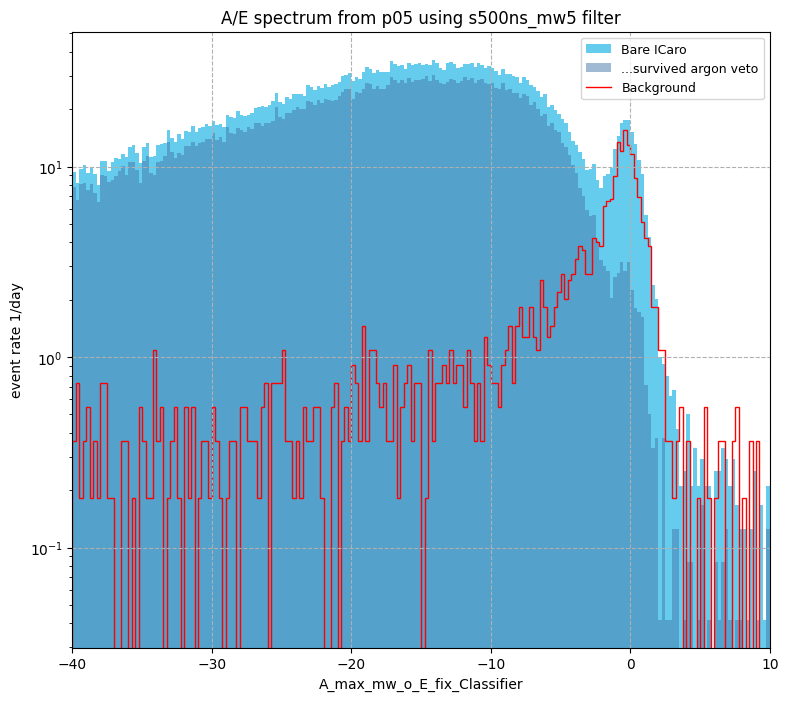

In [33]:
df_bg = dfs_sit_candidate["r038"]["ch002"]
mask_bg = r038_masks & candidate_roi_mask_r038
mask_low_cut_bg = mask_bg & df_bg.A_max_mw_o_E_fix_Low_Cut

df_phy_r059 = dfs_sit_candidate["r059"]["ch002"]
mask_phy_059 = r059_masks & candidate_roi_mask_r059
mask_low_cut_059 = mask_phy_059 & df_phy_r059.A_max_mw_o_E_fix_Low_Cut

# total = len(df_phy_r059[mask_phy])
df_phy_r060 = dfs_sit_candidate["r060"]["ch002"]
mask_phy_060 = r060_masks & candidate_roi_mask_r060
mask_low_cut_060 = mask_phy_060 & df_phy_r060.A_max_mw_o_E_fix_Low_Cut

aoe_phy_signal = ak.concatenate([df_phy_r059["A_max_mw_o_E_fix_Classifier"], df_phy_r060["A_max_mw_o_E_fix_Classifier"]])
phy_signal_mask = ak.concatenate([mask_phy_059, mask_phy_060])
phy_signal_low_cut_mask = ak.concatenate([mask_low_cut_059, mask_low_cut_060])
xrange = (-40, 10)
nbins = 200
fig, ax =plt.subplots(figsize=(9, 8))

vals, edges = np.histogram(aoe_phy_signal[phy_signal_mask], bins=nbins, range=xrange)
vals = vals/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

# vals_2, edges_2 = np.histogram(aoe_phy_signal[phy_signal_low_cut_mask], bins=nbins, range=xrange)
# vals_2 = vals_2/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

vals_3, edges_3 = np.histogram(df_bg[mask_bg]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
vals_3 = vals_3/lts_sit_candidate["r038"]/sec_to_day

# vals_4, edges_4 = np.histogram(df_bg[mask_low_cut_bg]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
# vals_4 = vals_4/lts_sit_candidate["r038"]/sec_to_day

vals_5, edges_5 = np.histogram(aoe_phy_signal[phy_signal_mask&~argon_mask], bins=nbins, range=xrange)
vals_5 = vals_5/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

# ax.stairs(vals, edges,fill=False,alpha=1,baseline=None)
ax.set_yscale("log")
ax.set_xlim(xrange)
ax.stairs(vals, edges,fill=True,alpha=1,color='#66CCEE')
ax.stairs(vals_5,edges_5,fill=True,alpha=0.5,color=cset.blue)
ax.stairs(vals_3, edges_3, fill=False,alpha=1,color="red")
plt.legend(["Bare ICaro","...survived argon veto", "Background"], loc="upper right",fontsize=9)
plt.title("A/E spectrum from p05 using " + candidate+ ' filter')
plt.ylabel("event rate 1/day")
plt.xlabel("A_max_mw_o_E_fix_Classifier")
plt.grid(linestyle='--')
# sf = accepted/total
# print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{total})")


Text(0.5, 0, 'trapEftp')

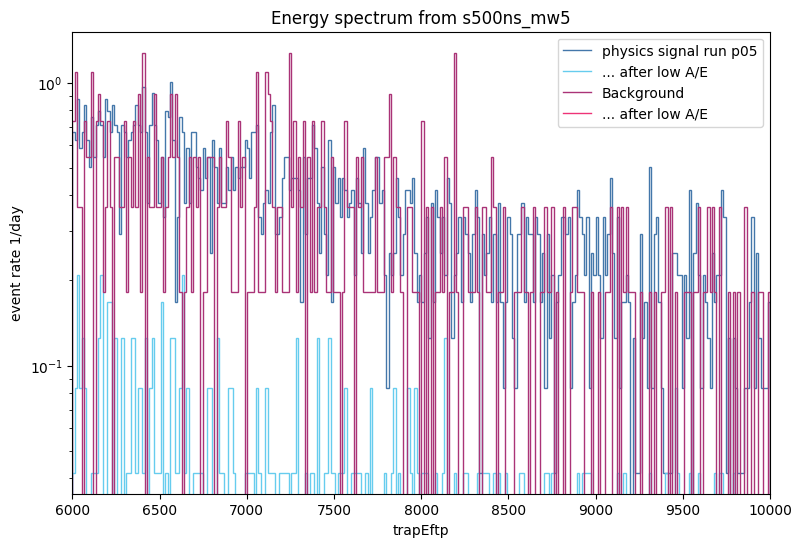

In [34]:
df_bg = dfs_sit_candidate["r038"]["ch002"]
Energy_bg = df_bg.trapEftp_fix_cal
mask_bg = r038_masks

mask_low_cut_bg = mask_bg & df_bg.A_max_mw_o_E_fix_Low_Cut
df_phy_r059 = dfs_sit_candidate["r059"]["ch002"]
mask_phy_059 = r059_masks 
mask_low_cut_059 = mask_phy_059 & df_phy_r059.A_max_mw_o_E_fix_Low_Cut

df_phy_r060 = dfs_sit_candidate["r060"]["ch002"]
mask_phy_060 = r060_masks 
mask_low_cut_060 = mask_phy_060 & df_phy_r060.A_max_mw_o_E_fix_Low_Cut
Energy = ak.concatenate([df_phy_r059.trapEftp_fix_cal, df_phy_r060.trapEftp_fix_cal])
mask_phy = ak.concatenate([mask_phy_059,mask_phy_060])
mask_low_cut = ak.concatenate([mask_low_cut_059,mask_low_cut_060])
xrange = (6000, 10000)
nbins = 300
fig, ax =plt.subplots(figsize=(9, 6))

vals, edges = np.histogram(Energy_bg[mask_bg],bins=nbins,range=xrange)
vals = vals/(lts_sit_candidate["r038"])/sec_to_day

vals_2, edges_2 = np.histogram(Energy_bg[mask_low_cut_bg],bins=nbins,range=xrange)
vals_2 = vals_2/(lts_sit_candidate["r038"])/sec_to_day

vals_3, edges_3 = np.histogram(Energy[mask_phy], bins=nbins, range=xrange)
vals_3 = vals_3/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day


vals_4, edges_4 = np.histogram(Energy[mask_low_cut], bins=nbins, range=xrange)
vals_4 = vals_4/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

ax.set_yscale("log")
ax.set_xlim(xrange)
ax.stairs(vals_3, edges_3, fill=False,alpha=1,color=cset.blue)
ax.stairs(vals_4, edges_4, fill=False,alpha=1,color=cset.cyan)
ax.stairs(vals ,edges ,fill=False,alpha=1,color=cset.purple)
ax.stairs(vals_2, edges_2, fill=False,alpha=1,color=cset2.magenta)

ax.axvline(x=1839, color="red", linestyle="--",linewidth=0.5)
ax.axvline(x=2239, color="red", linestyle="--",linewidth=0.5)

plt.legend(["physics signal run p05","... after low A/E","Background","... after low A/E"], loc="upper right")
plt.title("Energy spectrum from " +candidate)
plt.ylabel("event rate 1/day")
plt.xlabel("trapEftp")
# sf = accepted/total
# print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{total})")


Text(0.5, 0, 'trapEftp')

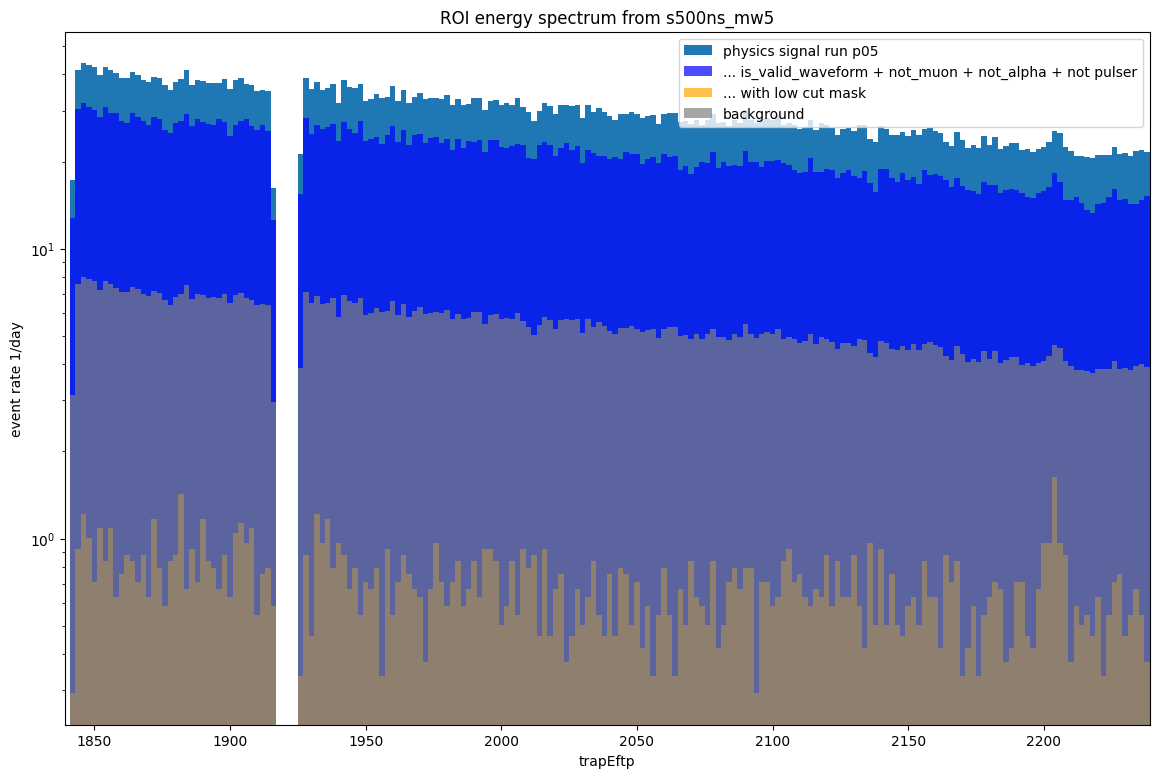

In [35]:
df_bg = dfs_sit_candidate["r038"]["ch002"]
Energy_bg = df_bg.trapEftp_fix_cal[candidate_roi_mask_r038]

df_phy_r059 = dfs_sit_candidate["r059"]["ch002"]
mask_phy_059 = r059_masks & candidate_roi_mask_r059
mask_low_cut_059 = mask_phy_059 & df_phy_r059.A_max_mw_o_E_fix_Low_Cut

# total = len(df_phy_r059[mask_phy])
df_phy_r060 = dfs_sit_candidate["r060"]["ch002"]
mask_phy_060 = r060_masks & candidate_roi_mask_r060
mask_low_cut_060 = mask_phy_060 & df_phy_r060.A_max_mw_o_E_fix_Low_Cut
Energy = ak.concatenate([df_phy_r059.trapEftp_fix_cal, df_phy_r060.trapEftp_fix_cal])
Energy_mask = ak.concatenate([candidate_roi_mask_r059,candidate_roi_mask_r060])
mask_phy = ak.concatenate([mask_phy_059,mask_phy_060])
mask_low_cut = ak.concatenate([mask_low_cut_059,mask_low_cut_060])
xrange = (1839, 2239)
nbins = 200
fig, ax =plt.subplots(figsize=(14, 9))

vals, edges = np.histogram(Energy[Energy_mask], bins=nbins, range=xrange)
vals = vals/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

vals_2, edges_2 = np.histogram(Energy_bg,bins=nbins,range=xrange)
vals_2 = vals/(lts_sit_candidate["r038"])/sec_to_day

vals_3, edges_3 = np.histogram(Energy[mask_phy], bins=nbins, range=xrange)
vals_3 = vals_3/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day


vals_4, edges_4 = np.histogram(Energy[mask_low_cut], bins=nbins, range=xrange)
vals_4 = vals_4/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day


ax.set_yscale("log")
ax.set_xlim(xrange)
# ax.set_ylim((-1e1,1.2e1))
ax.set_ylim(auto=True)
# ax.stairs(vals, edges,fill=False,alpha=1,baseline=None)
ax.stairs(vals, edges,fill=True,alpha=1)
ax.stairs(vals_3, edges_3, fill=True,alpha=0.7,color="blue")
ax.stairs(vals_4, edges_4, fill=True,alpha=0.7,color="orange")
ax.stairs(vals_2, edges_2, fill=True,alpha=0.7,color="grey")
separator = "-" * 3
plt.legend(["physics signal run p05","... is_valid_waveform + not_muon + not_alpha + not pulser","... with low cut mask","background"], loc="upper right")
plt.title("ROI energy spectrum from " +candidate)
plt.ylabel("event rate 1/day")
plt.xlabel("trapEftp")
# sf = accepted/total
# print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{total})")